# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

*We use these models because, at times, simple linear models are too limited for a lot of real-world problems. A linear model is just y = mx + b, which can't handle different types of outcomes (binary, categorical, etc...), and it is strictly a linear relationship in the output. General linear models and latent variable models keep the model linear internally, but transform the output using an activation function. This produces valid probabilities (between 0 and 1) and fixes the "linear probability model" issue. It can also handle many different types of outcomes (linear regression, logistic regression, multinomial logit) and it matches real-world processes better (like neuron firing).*

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

*They are effective loss functions because they align with probabilistic assumptions of logistic regression that arise from maximum likelihood estimation. They strongly penalize confident incorrect predictions, work naturally with sigmoid and softmax outputs, and provide stable gradients for optimization, making them more appropriate than losses like squared error for more probability-based models.*

3. True or false, and explain: Logistic regression is a linear model.

*True, logistic regression is a generalized linear model (GLM) that is linear in the latent variable (linear predictor) but nonlinear in its final output due to the activation function. The latent index is strictly linear in the parameters; this is why logistic regression is classified as a linear model.*

4. True or false, and explain: Logistic regression cannot be used for classification.

*False, logistic regression is specifically designed for classification tasks within GLMs and latent variable models. The model first computes a latent variable which is then passed through an activation function (sigmoid for binary classification and softmax for multiclass). This produces a predicted probability binary where you assign a value (like if probability is less than 0.5 predict class 0, otherwise predict class 0).*

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

*No, a coefficient is shown by the change in the log-odds (latent variable z) for a one-unit increase in x, holding other variables constant. It does not correlate to the direct change in the predicted probability because the model uses a nonlinear activation function (sigmoid), which  depends on the value of the latent index (gives nonlinear output).*

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

*False, logistic regression is a GLM that is linear in the latent variable, even though it applies nonlinear activation function to produce probabilities. Feature engineering is necessary because the model is linear in the inputs before the activation function. Without feature engineering, you would not be able to capture interactions between x's and nonlinear patterns (curves, x^2, etc...).*

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

*False, logistic regression is an improvement over OLS for binary/categorical outcomes because it models probabilities using a latent variable and activation function, ensuring valid predictions and aligning with a Bernoulli or categorical distribution; however, it is not universally better. OLS remains the appropriate model for many continuous outcomes. The choice depends on the type of dependent variable and the underlying assumptions of the model (you should not always use logistic regression instead of OLS).*

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout? 

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

## Question 2
The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

**Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.**

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/data.csv", delimiter=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [64]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [65]:
df_clean = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']]
df_clean.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [66]:
# check for missing values
df_clean.isna().sum() # showed no missing values, but we will drop any rows with missing values just in case

df_clean = df_clean.dropna()

In [67]:
# binary map
df_clean["Dropout"] =df_clean["Target"].map({
    "Dropout":1, 
    "Graduate":0,
    "Enrolled":0
})
df_clean.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


**Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?**

In [68]:
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df_clean[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df_clean['Dropout']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

reg = LogisticRegression(penalty=None,
                         max_iter
                         =5000)
reg = reg.fit(X_scaled,y)


pd.DataFrame({'Variable':X_scaled.columns,'Coefficient':reg.coef_[0]})

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Debtor,0.167209
1,Tuition fees up to date,-0.844779
2,Scholarship holder,-0.536713
3,Age at enrollment,0.378105


- Debtor and Age at enrollment variables tend to have a higher dropout probability (positive coefficient), and Tuition fees up to date and Scholarship holder have a decreased dropout probability (negative coefficient).
- Tuition fees being up to date seems to reduce dropout risk since it has the largest negative coefficient (-0.8).

 **Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?**

In [73]:
#dropout probability
dropout_prob = reg.predict_proba(X_scaled)[:, 1] # 0 = not dropout, 1 = dropout
print(dropout_prob)

[0.2547683  0.81495996 0.81495996 ... 0.1397826  0.08985079 0.27414991]


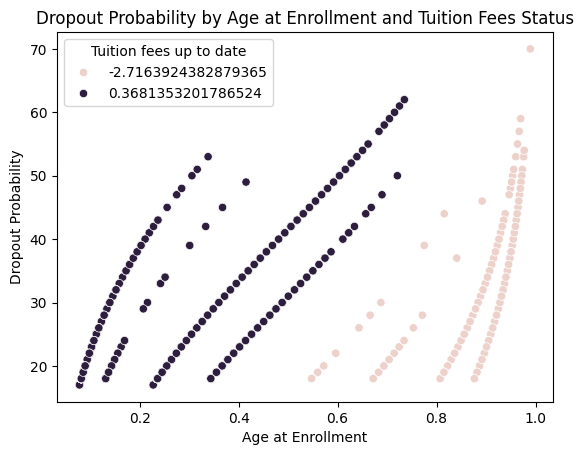

In [83]:
sns.scatterplot(y = df_clean['Age at enrollment'], x = dropout_prob, hue = X_scaled['Tuition fees up to date'])
plt.ylabel('Dropout Probability')
plt.xlabel('Age at Enrollment')
plt.title('Dropout Probability by Age at Enrollment and Tuition Fees Status')
plt.show()


- There is not a specific age when being up to date on tuition has the most reduction. Instead, the gap between students who are up to date on tuition, and those who are not, seems to be relatively consistent across all ages. This shows that being up to date on tuition reduces dropout risk at all ages, not one particular age.

In [78]:
# tuition vs dropout probability
mean = scaler.mean_[1]
std = scaler.scale_[1]

scaled_0 = (0 - mean) / std
scaled_1 = (1 - mean) / std

X1 = X_scaled.copy()
X0 = X_scaled.copy()

X1['Tuition fees up to date'] = scaled_1
X0['Tuition fees up to date'] = scaled_0

p1 = reg.predict_proba(X1)[:,1]
p0 = reg.predict_proba(X0)[:,1]

avg_effect = (p1 - p0).mean()
avg_effect

np.float64(-0.5233785825663483)

- On average, being up to date on tuition reduces the predicted probability of dropout by 53%.

**Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?**

In [80]:
y_class = pd.Series( reg.predict(X_scaled) )

tab = pd.crosstab( y_class, y)
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Dropout     0    1
row_0             
0        2841  891
1         162  530

Accuracy: 0.7619801084990958


- The accuracy is 76%

**Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.**

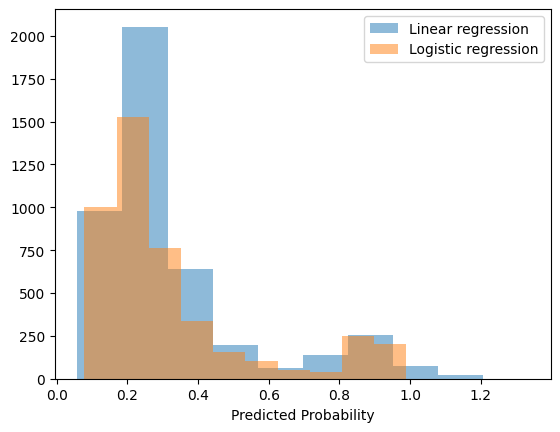

In [82]:
model = LinearRegression()
model.fit(X_scaled, y)
y_hat = model.predict(X_scaled)

plt.hist(x=y_hat, alpha = 0.5, label='Linear regression')
plt.hist(x=y_reg, alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show() 

- Linear regression produces predicted values outside the valid probability range, including values less than 0 and greater than 1. This occurs because linear regression does not constrain its outputs and assumes a linear relationship in the outcome. However, logistic regression produces predictions strictly between 0 and 1 due to the use of the sigmoid activation function. Logistic regression provides valid probability estimates and is more appropriate for modeling binary outcomes such as dropout.

**Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?**

- The students that are at most risk for dropping out are the ones who are not up to date on tuition, are debtors, or are not scholarship holders with tuition status being the best predictor
- The most useful interventions would probably be financial support and early outreach; for example, schools should push for a flexible payment plan, debt counseling, and strong scholarship support. Since many students face responsibilities of work or family obligations, institutions could also provide more academic support.

**Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?**

In [ ]:
y = df_clean['Target']
X = df_clean[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]

model = LogisticRegression(penalty=None, max_iter=5000).fit(X,y)

y_hat = model.predict(X)

# Confusion matrix
tab = pd.crosstab(y, y_hat)
print("Confusion matrix:\n", tab)

# Accuracy
acc = np.trace(tab) / len(y)
print("Accuracy:", acc)

probs = pd.DataFrame(model.predict_proba(X), columns = model.classes_)


Confusion matrix:
 col_0     Dropout  Graduate
Target                     
Dropout      1054       367
Enrolled      280       514
Graduate      146      2063
Accuracy: 0.35443037974683544


/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [85]:
print("Classes in y:", y.unique())
print("Classes predicted by .predict:", pd.Series(y_hat).unique())

print("Max predicted probability for each class:")
print(probs.max())

Classes in y: <ArrowStringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str
Classes predicted by .predict: <ArrowStringArray>
['Dropout', 'Graduate']
Length: 2, dtype: str
Max predicted probability for each class:
Dropout     0.960745
Enrolled    0.330229
Graduate    0.999723
dtype: float64


- No my hard classification does not predict every class (only Dropout and Graduate)
- Yes, my predicted probabilities does predict every class, but it predicts enrolled much less (33%)

## Question 3
The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

**Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.**

In [105]:
df = pd.read_csv("./data/cirrhosis.csv")
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [106]:
df_clean = df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]
df_clean.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [107]:
df_clean.isna().sum() # only missing values in Drug and Stage

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

In [ ]:
df_clean.shape # originally (418, 5)

(418, 5)

In [108]:
df_clean.dropna(inplace=True)

In [96]:
df_clean.shape # after dropping missing values (312, 5)

(312, 5)

**Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?**

In [109]:
# binary map
# 1 means alive, 0 means dead
df_clean["Status"] = df_clean["Status"].map({
    "C":1, 
    "CL":1,
    "D":0
})
df_clean.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,0
1,1.1,N,D-penicillamine,3.0,1
2,1.4,S,D-penicillamine,4.0,0
3,1.8,S,D-penicillamine,4.0,0
4,3.4,N,Placebo,3.0,1


In [127]:
X = df_clean[['Bilirubin', 'Edema', 'Drug']]
X = pd.get_dummies(X, drop_first=True)
y = df_clean['Status']

reg = LogisticRegression(penalty=None,
                         max_iter
                         =5000)
reg = reg.fit(X,y)


pd.DataFrame({'Variable':X.columns,'Coefficient':reg.coef_[0]})

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Bilirubin,-0.350381
1,Edema_S,-0.578551
2,Edema_Y,-2.859322
3,Drug_Placebo,0.252657


- The drug (D-penicillamine) does not seem to improve survivability. In fact, the model suggests that patients on the placebo have slightly higher survival probability. 
- Higher Bilirubin levels predict lower survival probability (lower Bilirubin has higher survival) based on the coefficients. 
- Compared to no edema, some edema has lower survival probability and yes to edema has much lower survival probability. 

**Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?**

In [ ]:
#survival probability
survival_prob = reg.predict_proba(X)[:, 1] # 0 = dead, 1 = alive
print(survival_prob[:10])

[0.00145537 0.73563312 0.58412456 0.54972903 0.61542476 0.799178
 0.78769524 0.82582976 0.57140672 0.00363807]


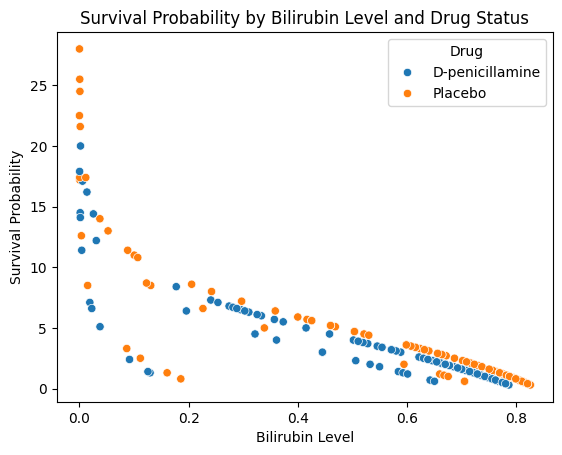

In [119]:
# scatter plot
sns.scatterplot(y = df_clean['Bilirubin'], x = survival_prob, hue = df_clean['Drug'])
plt.ylabel('Survival Probability')
plt.xlabel('Bilirubin Level')
plt.title('Survival Probability by Bilirubin Level and Drug Status')
plt.show()

- Having very small amounts of Bilirubin indicate higher survival probability (0 - 0.05).

In [121]:
X_drug = X.copy()
X_placebo = X.copy()

X_drug['Drug_Placebo'] = False
X_placebo['Drug_Placebo'] = True

p_drug = reg.predict_proba(X_drug)[:, 1]
p_placebo = reg.predict_proba(X_placebo)[:, 1]

# average increase in survival probability from taking the drug
avg_increase = (p_drug - p_placebo).mean()

print("Increase in survival probability from drug:", avg_increase)

Increase in survival probability from drug: -0.04506983805817702


- Survival probability does not increase from the drug. In fact, it goes down. This is also shown from the scatterplot. D-penicillamine (blue) is a little below the placebo line (orange.)

**Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?**

In [122]:
y_class = pd.Series(reg.predict(X))

tab = pd.crosstab(y_class, y)
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Status   0    1
row_0          
0       57   14
1       68  173

Accuracy: 0.7371794871794872


- Accuracy is 73%

**Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.**

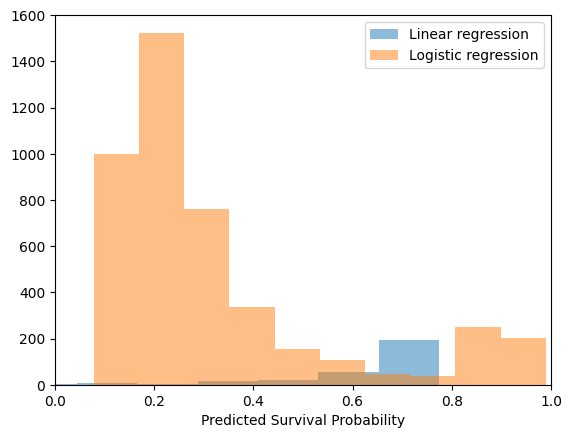

In [126]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

model = LinearRegression()
model.fit(X_scaled, y)
y_hat = model.predict(X_scaled)

plt.hist(x=y_hat, alpha = 0.5, label='Linear regression')
plt.hist(x=y_reg, alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Survival Probability')
plt.xlim(0,1)
plt.legend()
plt.show() 

- For logistic regression, it is right-skewed with most predictions clustered between 0.1 and 0.4.
- For linear regression, distribution is wider and more dispersed, and there is less clustering (it is more flat).

**Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?**

In [132]:
X = df_clean[['Bilirubin', 'Edema']]
X = pd.get_dummies(X, drop_first=True)
y = df_clean['Stage']

reg = LogisticRegression(penalty=None,
                         max_iter
                         =5000)
reg = reg.fit(X,y)


pd.DataFrame({'Variable':X.columns,'Coefficient':reg.coef_[0]})

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Bilirubin,-0.442467
1,Edema_S,-9.386613
2,Edema_Y,-4.528787


In [133]:
# Confusion matrix
y_class = pd.Series(reg.predict(X))

tab = pd.crosstab(y_class, y)
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Stage  1.0  2.0  3.0  4.0
row_0                    
3.0     16   61  102   74
4.0      0    6   18   35

Accuracy: 0.07051282051282051


- Model never predicts Stage 1 or 2, and it heavily predicts Stage 3 (even when it's wrong). Stage 4 is predicted sometimes but with many mistakes. The accuracy is very low.

In [134]:
# Does predicted probability predict every class?
probs = reg.predict_proba(X)
pd.DataFrame(probs, columns=reg.classes_).head()

,1.0,2.0,3.0,4.0
0,2.964590e-08,0.022548,0.124086,0.853367
1,7.611337e-02,0.252747,0.397286,0.273854
2,2.404137e-07,0.175628,0.404099,0.420273
3,1.886844e-07,0.170140,0.403070,0.426790
4,2.053812e-02,0.228845,0.425473,0.325145


- Yes, predicted probability does predict every class.

In [135]:
# Does hard classification predict every class?
pd.Series(reg.predict(X)).value_counts()

3.0    253
4.0     59
Name: count, dtype: int64

- No, the hard classification does not predict every class. It just predicts Stage 3 and 4. 

## Question 4
What are the coefficients of a logistic regression? How do you interpret their values?

# Part 1:
For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


## Answer:
- The linear model is:

$$
\hat{y} = b_0 + \sum_{k=1}^K b_k x_k
$$

- Taking the derivative of the prediction with respect to the $k$-th feature $x_k$:

$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

- This shows that the rate of change of the prediction with respect to $x_k$ is constant.

- For a 1-unit increase in $x_k$, the predicted value changes by:

$$
\Delta \hat{y} = b_k
$$
 
- A one-unit increase in the $k$-th feature increases the predicted value by $b_k$, holding all other variables constant. Because the model is linear, this effect is constant and does not depend on the value of $x_k$.
___________________________________________

# Part 2:
For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

## Answer: 

For the logistic model, the predicted probability is

$$
\hat{p}_i = \frac{e^{b \cdot x}}{1+e^{b \cdot x}}.
$$

Let

$$
L = b \cdot x = b_0 + \sum_{j=1}^K b_j x_j.
$$

Then

$$
\hat{p}_i = \frac{e^L}{1+e^L}.
$$

Using the chain rule,

$$
\frac{\partial \hat{p}_i}{\partial x_k}
=
\frac{\partial \hat{p}_i}{\partial L}\cdot \frac{\partial L}{\partial x_k}.
$$

From the hint,

$$
\frac{\partial \hat{p}_i}{\partial L}
=
\hat{p}_i(1-\hat{p}_i),
$$

and since

$$
L = b_0 + \sum_{j=1}^K b_j x_j,
\qquad
\frac{\partial L}{\partial x_k} = b_k,
$$

we get

$$
\frac{\partial \hat{p}_i}{\partial x_k}
=
\hat{p}_i(1-\hat{p}_i)b_k.
$$

### Does this change as x changes?

Yes. Unlike the linear model, this derivative depends on $\hat{p}_i$, and $\hat{p}_i$ depends on $x$. So the effect of a 1-unit change in $x_k$ is not constant.

As $x$ changes, the predicted probability changes, so the quantity

$$
\hat{p}_i(1-\hat{p}_i)b_k
$$

also changes.

### How is this similar to or different from part 1?

In part 1 (the linear model),

$$
\frac{\partial \hat{y}}{\partial x_k} = b_k,
$$

so a 1-unit increase in $x_k$ always changes the prediction by exactly $b_k$.

In the logistic model, the coefficient $b_k$ still appears, but it is multiplied by

$$
\hat{p}_i(1-\hat{p}_i),
$$

so the effect depends on where you are on the sigmoid curve.

- In the linear model, the marginal effect is constant.
- In the logistic model, the marginal effect varies with the predicted probability.

### When is the coefficient itself (times 4) a good approximation?

The term

$$
\hat{p}_i(1-\hat{p}_i)
$$

is maximized when

$$
\hat{p}_i = 0.5.
$$

At that point,

$$
\hat{p}_i(1-\hat{p}_i) = 0.5(1-0.5)=0.25.
$$

So near $\hat{p}_i = 0.5$,

$$
\frac{\partial \hat{p}_i}{\partial x_k} \approx 0.25\, b_k = \frac{b_k}{4}.
$$

Multiplying the derivative by 4 gives something close to the coefficient:

$$
b_k \approx 4 \cdot \frac{\partial \hat{p}_i}{\partial x_k}
\qquad \text{when } \hat{p}_i \approx 0.5.
$$

So the coefficient itself (or the derivative times 4) is a roughly good estimate of the effect of a change in $x_k$ when the predicted probability is near 0.5 (in the middle of the sigmoid where the curve is steepest).


A 1-unit increase in $x_k$ changes the predicted probability by approximately

$$
\hat{p}_i(1-\hat{p}_i)b_k.
$$

This is similar to the linear model because the coefficient $b_k$ still determines the direction of the effect, but it is different because the magnitude is no longer constant. The effect is largest when $\hat{p}_i$ is near $0.5$ and smallest when $\hat{p}_i$ is near $0$ or $1$.
____________________________________________________

# Part 3:
Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

## Answer:

From the transformation:

$$
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k
$$

you can see that the log-odds ratio is a linear function of the features.

Taking the derivative with respect to the $k$-th feature:

$$
\frac{\partial}{\partial x_k} \log \left( \frac{\hat{p}}{1-\hat{p}} \right) = b_k
$$

A one-unit increase in $x_k$ changes the log-odds ratio by:

$$
\Delta \log \left( \frac{\hat{p}}{1-\hat{p}} \right) = b_k
$$


Unlike the predicted probability $\hat{p}$, which changes nonlinearly, the log-odds ratio changes linearly with $x_k$.

- The effect of $x_k$ on the log-odds is constant
- A 1-unit increase in $x_k$ always increases (or decreases) the log-odds by $b_k$


A one-unit increase in $x_k$ increases the log-odds of the outcome by $b_k$, holding all other variables constant.